# YOLO data augmentation — before tiling

This notebook previews and exports **YOLO-label-aware** augmentation for the traffic-object dataset. Augment the full source images first, then tile the resulting dataset. Tiling after augmentation preserves the natural scene context while still making small objects larger in the final training tiles.

The default policy is deliberately conservative. The other policies are ablations for specific failure modes, rather than transformations to enable all at once.

## Workflow

1. Set `reference_path` and inspect the same image with each policy.
2. Start with `baseline`; compare one targeted policy at a time on the unchanged validation split.
3. Export original + augmented **training** images to a new pre-tiling directory. Validation is copied without augmentation.
4. Tile that new directory, then train YOLO on the tiled `data.yaml`.

Vertical flips, 90° rotations, and aggressive random crops are intentionally excluded: they create implausible road scenes or discard the small objects that the later tiling stage is meant to retain.

In [ ]:
!pip install -U albumentationsx


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.augmentation import (
    copy_yolo_split,
    export_augmented_split,
    make_augmentation_policies,
    plot_augmentation_comparison,
    write_yolo_data_yaml,
)
from src.constants import CLASS_NAMES

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", None)

In [2]:
# Change these two paths when switching from the small sample to the full dataset.
DATASET_ROOT = Path("data_small")
reference_path = DATASET_ROOT / "images" / "train" / "9999942_00000_d_0000142.jpg"

POLICY_SEED = 42  # reproducible augmentation sequence for comparisons and exports

if not reference_path.is_file():
    raise FileNotFoundError(f"Update reference_path; image not found: {reference_path}")

print(f"Dataset: {DATASET_ROOT.resolve()}")
print(f"Comparison image: {reference_path}")

Dataset: /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data_small
Comparison image: data_small/images/train/9999942_00000_d_0000142.jpg


## Comparable policies

Every policy updates the corresponding normalized YOLO boxes. `baseline` combines a small horizontal/viewpoint change with light color and camera-quality variation. The specialist policies target one source of domain shift each; only promote one to the combined `strong` policy if its individual ablation improves validation metrics.

In [3]:
policies = make_augmentation_policies(seed=POLICY_SEED)

policy_catalog = pd.DataFrame([
    {"policy": policy.name, "purpose": policy.purpose}
    for policy in policies.values()
])
policy_catalog

/home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/src/augmentation.py:100: UserWarning: Argument(s) 'brightness_limit, contrast_limit' are not valid for transform RandomBrightnessContrast
  A.RandomBrightnessContrast(
/home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/src/augmentation.py:105: UserWarning: Argument(s) 'hue_shift_limit, sat_shift_limit, val_shift_limit' are not valid for transform HueSaturationValue
  A.HueSaturationValue(
/home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/src/augmentation.py:114: UserWarning: Argument(s) 'blur_limit' are not valid for transform GaussianBlur
  A.GaussianBlur(blur_limit=(3, 5), p=1.0),
/home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/src/augmentation.py:131: UserWarning: Argument(s) 'brightness_limit, contrast_limit' are not valid for transform RandomBrightnessContrast
  A.RandomBrightnessContrast(
/home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/src/augmentation.py:136: UserWarning: Argument(s) 'gamma_l

,policy,purpose
0,baseline,"Mild left/right viewpoint, exposure, and compression variation for normal training."
1,lighting,"Dawn, dusk, backlight, and automatic-exposure robustness."
2,degradation,"Motion, focus, sensor-noise, and lossy-stream robustness."
3,weather,Weather and cast-shadow robustness; enable only if it matches deployment data.
4,occlusion,"Partial-object robustness for traffic, poles, and overlapping vehicles."
5,strong,A deliberately harder mixed policy; use only after individual ablations validate it.


## Compare augmentations on `reference_path`

The source image is always `reference_path`. Box counts are shown in each panel so a geometry transform that removes boxes is immediately visible. Rebuild `policies` before a repeatable fresh comparison because each policy advances its own seeded random stream on every call.

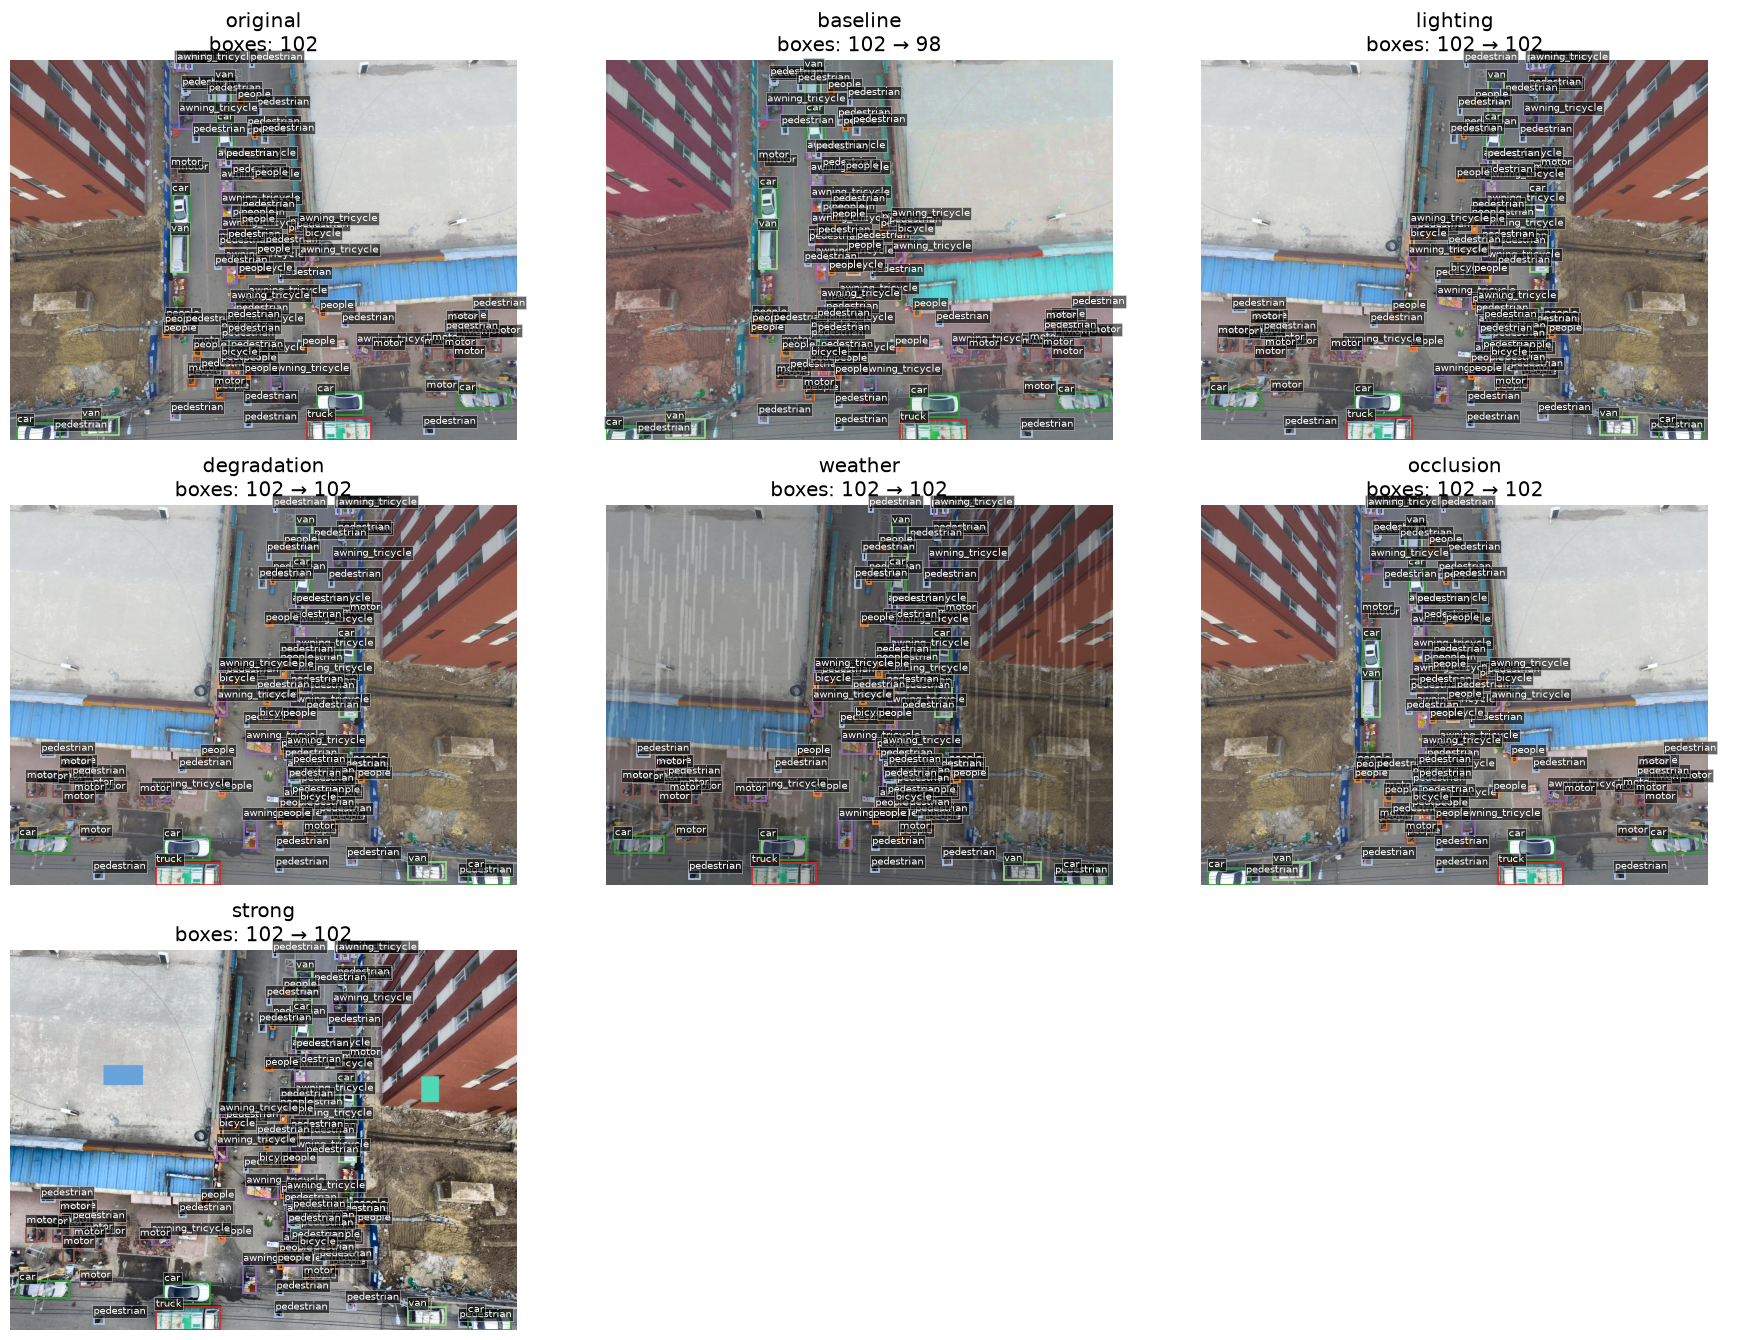

In [4]:
COMPARE_POLICIES = ["baseline", "lighting", "degradation", "weather", "occlusion", "strong"]

figure = plot_augmentation_comparison(
    reference_path=reference_path,
    policies=policies,
    policy_names=COMPARE_POLICIES,
    class_names=CLASS_NAMES,
    columns=3,
)
plt.show()

## Baseline export for YOLO training

The next cell is opt-in because it writes a new dataset. It exports one baseline-augmented copy per training image and retains the original, so the tiler receives both variants. It never modifies `DATASET_ROOT` and refuses to overwrite an existing target split. Keep validation unaugmented to make model comparisons meaningful.

In [ ]:
TRAINING_POLICY_NAME = "baseline"
COPIES_PER_IMAGE = 1  # originals + one augmented copy is the initial baseline
PRE_TILE_DATASET_ROOT = Path("data_small_augmented_pre_tile")
EXPORT_PRE_TILE_DATASET = False  # change to True only when the preview looks realistic

training_policy = policies[TRAINING_POLICY_NAME]
print(f"Selected policy: {training_policy.name}")
print(training_policy.purpose)

In [ ]:
if EXPORT_PRE_TILE_DATASET:
    # Rebuild so preview calls do not advance the random stream used for export.
    export_policy = make_augmentation_policies(seed=POLICY_SEED)[TRAINING_POLICY_NAME]
    train_summary = export_augmented_split(
        dataset_root=DATASET_ROOT,
        output_root=PRE_TILE_DATASET_ROOT,
        policy=export_policy,
        split="train",
        copies_per_image=COPIES_PER_IMAGE,
        include_originals=True,
    )
    validation_images = copy_yolo_split(DATASET_ROOT, PRE_TILE_DATASET_ROOT, split="val")
    data_yaml = write_yolo_data_yaml(
        PRE_TILE_DATASET_ROOT,
        class_names=CLASS_NAMES,
    )
    print(train_summary)
    print(f"Copied {validation_images} untouched validation images.")
    print(f"Pre-tiling data config: {data_yaml}")

## Tile, then train

Run the project’s tiling workflow on `PRE_TILE_DATASET_ROOT` after the export completes. Tile both `train` and the untouched `val` split with the same tile size and overlap settings. Train YOLO from the tiled dataset’s `data.yaml`; do not pass this Albumentations object directly to `model.train`, because the labels have already been transformed and written safely here.

For a fair regularization comparison, hold fixed the model, tile configuration, epochs, image size, random seed, and validation set. Change only `TRAINING_POLICY_NAME` (and use a different output directory for each run).

In [ ]:
# After tiling, point YOLO to the tiled output rather than PRE_TILE_DATASET_ROOT.
# from src.training import train_model
# results = train_model(
#     data_config=Path("data_small_tiled/data.yaml"),
#     weights="yolo11n.pt",
#     epochs=100,
#     image_size=640,
#     batch=16,
#     name=f"visdrone_{TRAINING_POLICY_NAME}",
# )

## Suggested regularization ablation order

Run `baseline` first. Add `lighting` for exposure failures, `degradation` for blur/noise/compression failures, `weather` only when that condition occurs in deployment, and `occlusion` when partial objects are common. Reserve `strong` for a final experiment; it is not a safe default simply because it contains more transformations.

In [ ]:
EXPERIMENTS = [
    {"run_name": "baseline", "policy": "baseline", "copies_per_image": 1},
    {"run_name": "lighting", "policy": "lighting", "copies_per_image": 1},
    {"run_name": "degradation", "policy": "degradation", "copies_per_image": 1},
    {"run_name": "occlusion", "policy": "occlusion", "copies_per_image": 1},
]

pd.DataFrame(EXPERIMENTS)